In [1]:
from keras.datasets import mnist
from keras.utils import to_categorical
from keras import models , layers
import matplotlib.pyplot as plt
import numpy as np

/Users/ponlawatchangto/Desktop/VsCode/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
(train_x,train_y) , (test_x,test_y) = mnist.load_data()

In [3]:
print(f"train_x.shape : {train_x.shape}")
print(f"train_y.shape : {train_y.shape}")
print(f"test_x.shape : {test_x.shape}")
print(f"test_y.shape : {test_y.shape}")

train_x.shape : (60000, 28, 28)
train_y.shape : (60000,)
test_x.shape : (10000, 28, 28)
test_y.shape : (10000,)


In [4]:
train_x = train_x.reshape(train_x.shape[0],28*28).astype('float32') / 255
test_x = test_x.reshape(test_x.shape[0],28*28).astype('float32') / 255

test_y = to_categorical(test_y)
train_y = to_categorical(train_y)

In [5]:
val_x = train_x[50000:]
val_y = train_y[50000:]

train_x = train_x[:50000]
train_y = train_y[:50000]

In [11]:
classNum = train_y.shape[1]

model = models.Sequential([
    layers.Dense(96,activation='relu',input_shape=(28*28,)),
    layers.Dense(32,activation='relu'),
    layers.Dense(classNum , activation='softmax')
])

model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])

In [12]:
history = model.fit(train_x,train_y,epochs=28,batch_size=1024,validation_data=(val_x,val_y))

Epoch 1/28
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7705 - loss: 0.8839 - val_accuracy: 0.9046 - val_loss: 0.3790
Epoch 2/28
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9018 - loss: 0.3541 - val_accuracy: 0.9115 - val_loss: 0.3052
Epoch 3/28
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9230 - loss: 0.2715 - val_accuracy: 0.9314 - val_loss: 0.2414
Epoch 4/28
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9337 - loss: 0.2316 - val_accuracy: 0.9419 - val_loss: 0.2082
Epoch 5/28
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9420 - loss: 0.2008 - val_accuracy: 0.9509 - val_loss: 0.1797
Epoch 6/28
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9481 - loss: 0.1788 - val_accuracy: 0.9534 - val_loss: 0.1679
Epoch 7/28
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9538 - loss: 0.1590 - val_accuracy: 0.9585 - val_loss: 0.1492
Epoch 8/28
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9585 - loss: 0.1434 - val_accuracy: 0.9627 - val_loss:

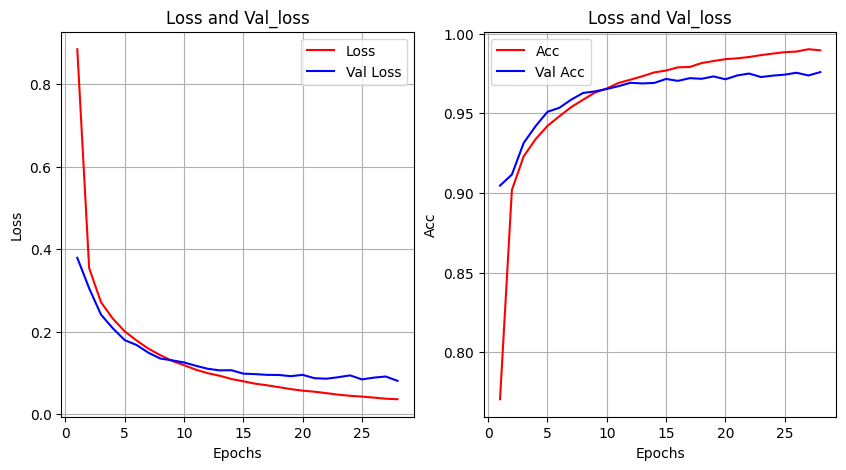

In [13]:
loss = history.history['loss']
acc = history.history['accuracy']
val_loss = history.history['val_loss']
val_acc = history.history['val_accuracy']
epochs = range(1,len(loss)+1)

size=5
plt.figure(figsize=(size*2,size))

plt.subplot(1,2,1)
plt.title('Loss and Val_loss')
plt.grid(True)
plt.plot(epochs,loss,'r',label='Loss')
plt.plot(epochs,val_loss,'b',label='Val Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.title('Loss and Val_loss')
plt.grid(True)
plt.plot(epochs,acc,'r',label='Acc')
plt.plot(epochs,val_acc,'b',label='Val Acc')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Acc')

plt.show()

In [14]:
loss , acc = history.model.evaluate(test_x,test_y)
print(loss)
print(acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 324us/step - accuracy: 0.9765 - loss: 0.0772
0.07719267159700394
0.9764999747276306


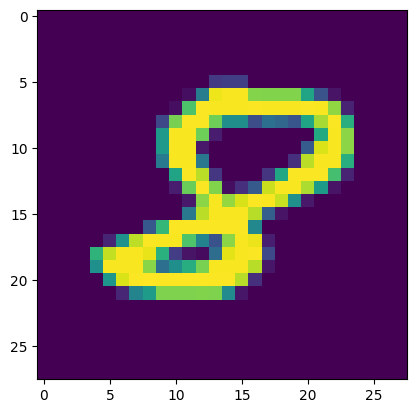

predict : 2
answer : 8


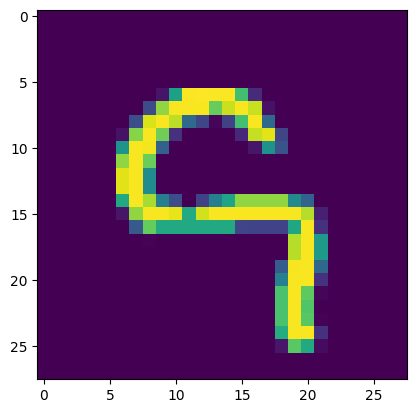

predict : 5
answer : 9


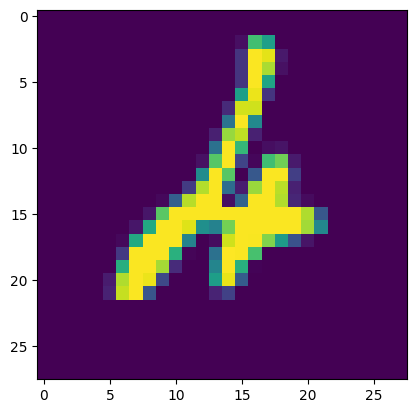

predict : 2
answer : 4


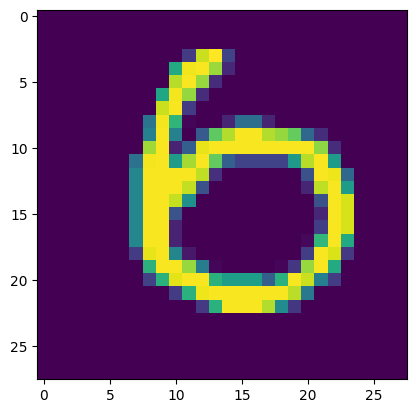

predict : 0
answer : 6
score = 296


In [15]:
score = 0
for index in range(1,301) :
    # print(test_x[index].shape)
    # plt.imshow(test_x[index].reshape(28, 28))
    # print(test_x[index].reshape(28, 28).shape)
    # plt.show()

    # sample = np.expand_dims(test_x[index], axis=0)  # หรือ test_x[index:index+1]
    sample = np.array([test_x[index]])
    # print(sample.shape)
    prediction = model.predict(sample, verbose=0)
    predicted_digit = np.argmax(prediction[0])      # MNIST คือเลข 0-9
    # print(f"Predicted digit: {predicted_digit}")
    answer = np.where(test_y[index] == 1)[0][0]
    # print(f"Answer : {answer}")
    if answer == predicted_digit :
        score += 1
    else :
        plt.imshow(test_x[index].reshape(28, 28))
        plt.show()
        print(f"predict : {predicted_digit}")
        print(f"answer : {answer}")
        
print(f"score = {score}")